# 03 — Training: EfficientNetB3 Transfer Learning
WBC Classification · 9 classes · 300×300 input

**Two-phase strategy:**
- **Phase 1** — Frozen EfficientNetB3 base, train classification head only (10–15 epochs)
- **Phase 2** — Unfreeze top ~85 layers, fine-tune with very low LR (15–20 epochs)

Start with Phase 1 to stabilise the head weights before unfreezing.
This prevents early fine-tuning from destroying ImageNet features.

In [1]:
import sys
sys.path.append('../src')

import os
import numpy as np
import tensorflow as tf
from pathlib import Path
from datetime import datetime

from dataset import build_dataset, get_class_weights, CLASSES, NUM_CLASSES
from model   import build_model, compile_phase1, compile_phase2, unfreeze_top_layers
from utils   import plot_training_history

print('TensorFlow version:', tf.__version__)
print('GPUs available    :', tf.config.list_physical_devices('GPU'))

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR     = Path('../data/processed')
MODELS_DIR   = Path('../models')
RESULTS_DIR  = Path('../results')
CKPT_DIR     = MODELS_DIR / 'checkpoints'
FINAL_DIR    = MODELS_DIR / 'final'

for d in [CKPT_DIR, FINAL_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TensorFlow version: 2.10.0
GPUs available    : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Hyperparameters
Tune these first if results are poor — batch size and learning rate are the most impactful.

In [2]:
# ── Hyperparameters ────────────────────────────────────────────────────────
BATCH_SIZE     = 32      # Reduce to 16 if OOM; increase to 64 on high-VRAM GPU
PHASE1_EPOCHS  = 15      # Head-only warmup
PHASE2_EPOCHS  = 20      # Fine-tuning unfrozen top layers
PHASE1_LR      = 1e-3
PHASE2_LR      = 1e-5    # Must be much lower to avoid destroying ImageNet weights
USE_CLASS_WEIGHTS = False#True # Recommended if imbalance ratio > 3× (check EDA notebook)

## Data Pipelines

In [3]:
train_ds = build_dataset(DATA_DIR / 'train', batch_size=BATCH_SIZE, augment=True,  shuffle=True)
val_ds   = build_dataset(DATA_DIR / 'val',   batch_size=BATCH_SIZE, augment=False, shuffle=False)

# Class weights for imbalanced dataset
class_weights = get_class_weights(DATA_DIR / 'train') if USE_CLASS_WEIGHTS else None
if class_weights:
    print('\nClass weights:')
    for i, cls in enumerate(CLASSES):
        print(f'  [{i}] {cls:<25s}: {class_weights[i]:.3f}')

[dataset] train: 9613 images across 9 classes
[dataset] val: 3202 images across 9 classes


## Build Model

In [4]:
def fix_rescaling(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):  # EfficientNet block
            for sublayer in layer.layers:
                if isinstance(sublayer, tf.keras.layers.Rescaling):
                    scale = sublayer.scale

                    if isinstance(scale, tf.Tensor):
                        sublayer.scale = scale.numpy().tolist()
                        print(f"Fixed: {sublayer.name}")

    return model

In [5]:
model = build_model(num_classes=NUM_CLASSES)
model = fix_rescaling(model)
model.summary(line_length=90, expand_nested=False)

Fixed: rescaling_1
Model: "EfficientNetB3_WBC"
__________________________________________________________________________________________
 Layer (type)                           Output Shape                        Param #       
 input_image (InputLayer)               [(None, 300, 300, 3)]               0             
                                                                                          
 efficientnetb3 (Functional)            (None, 10, 10, 1536)                10783535      
                                                                                          
 gap (GlobalAveragePooling2D)           (None, 1536)                        0             
                                                                                          
 bn_head (BatchNormalization)           (None, 1536)                        6144          
                                                                                          
 dropout_1 (Dropout)                    (No

## Phase 1 — Train Classification Head (base frozen)

In [6]:
model = compile_phase1(model, learning_rate=PHASE1_LR)

callbacks_p1 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(CKPT_DIR / 'phase1_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        save_weights_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.TensorBoard(
        log_dir=str(RESULTS_DIR / 'logs' / 'phase1'),
        histogram_freq=1,
    ),
]

history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    callbacks=callbacks_p1,
    #class_weight=class_weights,
)

print('\nPhase 1 complete.')
print(f'Best val accuracy: {max(history_p1.history["val_accuracy"]):.4f}')

  Total params     : 11,185,464
  Trainable params : 398,857  (3.6%)
  Frozen params    : 10,786,607
Epoch 1/15
301/301 [==============================] - ETA: 0s - loss: 0.9252 - accuracy: 0.7434 - auc: 0.9527
Epoch 1: val_accuracy improved from -inf to 0.89382, saving model to ..\models\checkpoints\phase1_best.keras
301/301 [==============================] - 80s 246ms/step - loss: 0.9252 - accuracy: 0.7434 - auc: 0.9527 - val_loss: 0.4387 - val_accuracy: 0.8938 - val_auc: 0.9924 - lr: 0.0010
Epoch 2/15
301/301 [==============================] - ETA: 0s - loss: 0.6040 - accuracy: 0.8297 - auc: 0.9779
Epoch 2: val_accuracy improved from 0.89382 to 0.91474, saving model to ..\models\checkpoints\phase1_best.keras
301/301 [==============================] - 62s 204ms/step - loss: 0.6040 - accuracy: 0.8297 - auc: 0.9779 - val_loss: 0.3157 - val_accuracy: 0.9147 - val_auc: 0.9941 - lr: 0.0010
Epoch 3/15
301/301 [==============================] - ETA: 0s - loss: 0.4959 - accuracy: 0.8574 - au

[utils] Training curves saved → ..\results\phase1_training_curves.png


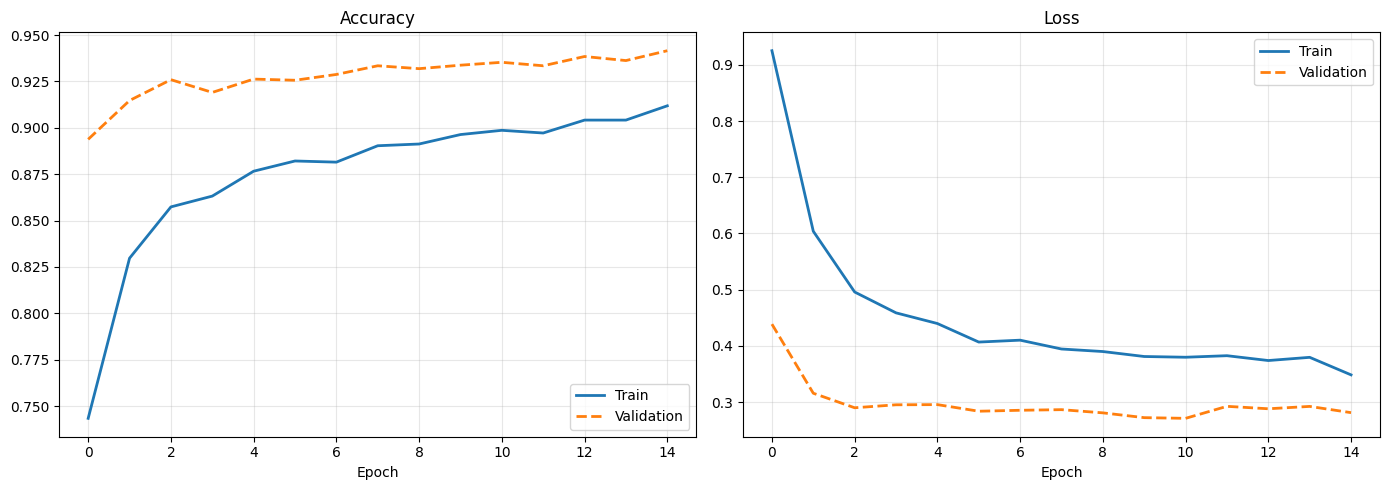

In [7]:
plot_training_history(
    history_p1.history,
    save_path=RESULTS_DIR / 'phase1_training_curves.png'
)

## Phase 2 — Fine-tune Top Layers (partial unfreeze)

We unfreeze layers from `UNFREEZE_FROM_LAYER` onwards in EfficientNetB3.
All BatchNormalization layers stay frozen — this is critical for stability.

Using SGD + Nesterov momentum at LR=1e-5 (much safer than Adam for fine-tuning).

In [8]:
# Load best Phase 1 weights before unfreezing
model.load_weights(str(CKPT_DIR / 'phase1_best.keras'))

model = unfreeze_top_layers(model)
model = compile_phase2(model, learning_rate=PHASE2_LR)

callbacks_p2 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(CKPT_DIR / 'phase2_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        save_weights_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
    tf.keras.callbacks.TensorBoard(
        log_dir=str(RESULTS_DIR / 'logs' / 'phase2'),
        histogram_freq=1,
    ),
]

history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE2_EPOCHS,
    callbacks=callbacks_p2,
    class_weight=class_weights,
)

print('\nPhase 2 complete.')
print(f'Best val accuracy: {max(history_p2.history["val_accuracy"]):.4f}')

  Total params     : 11,185,464
  Trainable params : 7,273,275  (65.0%)
  Frozen params    : 3,912,189
Epoch 1/20
301/301 [==============================] - ETA: 0s - loss: 0.3180 - accuracy: 0.9220 - auc: 0.9958
Epoch 1: val_accuracy improved from -inf to 0.94722, saving model to ..\models\checkpoints\phase2_best.keras
301/301 [==============================] - 75s 234ms/step - loss: 0.3180 - accuracy: 0.9220 - auc: 0.9958 - val_loss: 0.2689 - val_accuracy: 0.9472 - val_auc: 0.9972 - lr: 1.0000e-05
Epoch 2/20
301/301 [==============================] - ETA: 0s - loss: 0.3146 - accuracy: 0.9227 - auc: 0.9960
Epoch 2: val_accuracy improved from 0.94722 to 0.95003, saving model to ..\models\checkpoints\phase2_best.keras
301/301 [==============================] - 69s 229ms/step - loss: 0.3146 - accuracy: 0.9227 - auc: 0.9960 - val_loss: 0.2638 - val_accuracy: 0.9500 - val_auc: 0.9973 - lr: 1.0000e-05
Epoch 3/20
301/301 [==============================] - ETA: 0s - loss: 0.3108 - accuracy: 0

[utils] Training curves saved → ..\results\phase2_training_curves.png


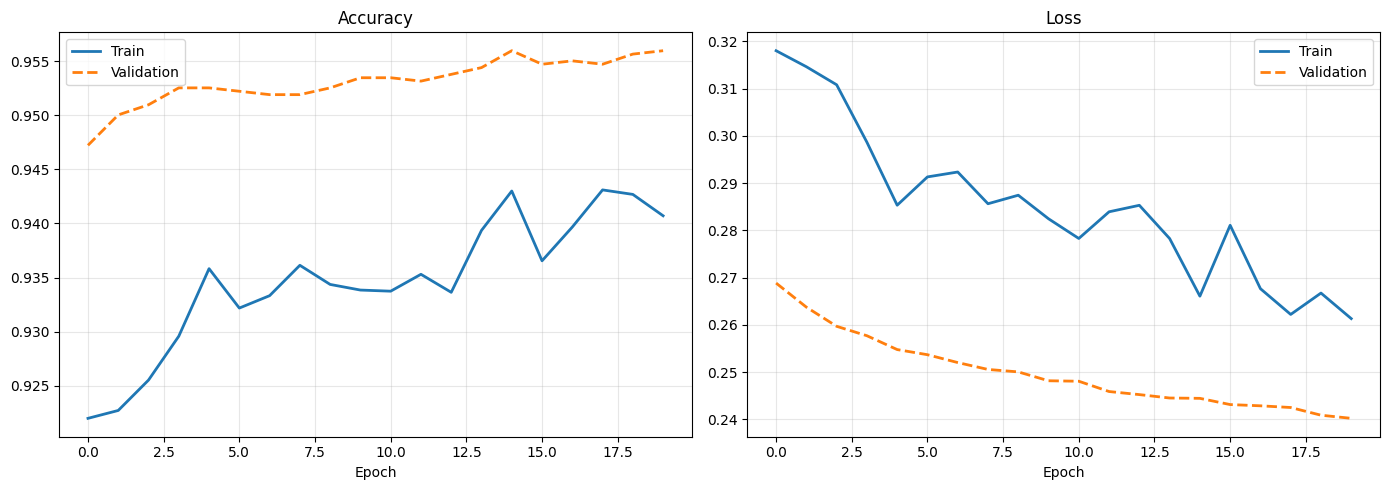

In [9]:
plot_training_history(
    history_p2.history,
    save_path=RESULTS_DIR / 'phase2_training_curves.png'
)

## Save Final Model

In [10]:
# Load best Phase 2 weights
model.load_weights(str(CKPT_DIR / 'phase2_best.keras'))

In [11]:

# Save in native Keras format
final_path = FINAL_DIR / 'efficientnetb3_wbc_final.keras'
model.save(final_path)
print(f'Final model saved → {final_path}')


Final model saved → ..\models\final\efficientnetb3_wbc_final.keras


In [12]:
# Quick sanity check on validation set
val_loss, val_acc, val_auc = model.evaluate(val_ds, verbose=1)
print(f'\nValidation  accuracy: {val_acc:.4f}')
print(f'Validation  AUC     : {val_auc:.4f}')
print(f'Validation  loss    : {val_loss:.4f}')

101/101 [==============================] - 15s 149ms/step - loss: 0.2445 - accuracy: 0.9560 - auc: 0.9973

Validation  accuracy: 0.9560
Validation  AUC     : 0.9973
Validation  loss    : 0.2445


In [9]:
model.get_config()

{'name': 'EfficientNetB3_WBC',
 'layers': [{'class_name': 'InputLayer',
   'config': {'batch_input_shape': (None, 300, 300, 3),
    'dtype': 'float32',
    'sparse': False,
    'ragged': False,
    'name': 'input_image'},
   'name': 'input_image',
   'inbound_nodes': []},
  {'class_name': 'Functional',
   'config': {'name': 'efficientnetb3',
    'layers': [{'class_name': 'InputLayer',
      'config': {'batch_input_shape': (None, 300, 300, 3),
       'dtype': 'float32',
       'sparse': False,
       'ragged': False,
       'name': 'input_2'},
      'name': 'input_2',
      'inbound_nodes': []},
     {'class_name': 'Rescaling',
      'config': {'name': 'rescaling_2',
       'trainable': False,
       'dtype': 'float32',
       'scale': 0.00392156862745098,
       'offset': 0.0},
      'name': 'rescaling_2',
      'inbound_nodes': [[['input_2', 0, 0, {}]]]},
     {'class_name': 'Normalization',
      'config': {'name': 'normalization_1',
       'trainable': False,
       'dtype': 'float3